In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as ss
from scipy.interpolate import pchip_interpolate

from genetic_algorithm_pfm import GeneticAlgorithm
from genetic_algorithm_pfm.tetra_pfm import TetraSolver

%matplotlib inline

In [2]:
## define variables

# x1 : The length of the tunnel
# x2 : The number of lanes
# x3 : The depth of the tunnel

In [3]:
## define functions

# The cost function

def objective_costs(x1, x2, x3):
    return C6 * B1 * x1 + C2 * C6 * x2 + C6 * C1 * x3

# The emission function

def objective_emissions(x1, x2, x3):
    return C3 * B1 * x1 + C2 * C3 * x2 + C3 * C1 * x3

# The traffic flow function

def objective_traffic_flow(x1, x2):
    return B2 * B3 * x2 / (x1 * 10**-3)              ## to km

# The Travel time function

def objective_travel_time(x1, x2):
    return (x1*10**-3 /  B2 )  * np.exp(-B4 * x2)    ## to km


In [4]:
## bounds

b1 = (815, 1035)   # min and max for x1
b2 = (2, 8)        # min and max for x2
b3 = (24.4, 30.7)  # min and max for x3

bounds = [b1, b2, b3]

In [5]:
B1 = 211680          # [kg/m]    mass per length
C1 = 39584067        # [kg/m]    mass per depth
C2 = 6234971         # [kg/n]    mass per lane
C3 = 0.12            # [CO2/kg]  CO2 per kg concrete
C6 = 0.125           # [€/ kg]   price per kg concrete
B2 = 100             # [km/h]    speed
B3 = 50              # [veh]     number of Trucks in the tunnel
B4 = 0.2             # [-]       decay rate

In [10]:
# Initialize TetraSolver
solver = TetraSolver()

# set weights for the different objectives
w1 = 0.3
w2 = 0.1
w3 = 0.3
w4 = 0.3

# x_points: the outcomes of the objective for which a preference score is defined by the stakeholders
# p_points: the corresponding preference scores

## arange the x_points and define the p_points, 
x_points_1, p_points_1 = [[objective_costs(b1[0], b2[0], b3[0]),
                           objective_costs(b1[0], b2[1], b3[0]), 
                           objective_costs(b1[1], b2[0], b3[1]),
                           objective_costs(b1[1], b2[1], b3[1])],
                          [100, 70, 0,0]]

x_points_2, p_points_2 = [[objective_emissions(b1[0], b2[0], b3[0]),
                           objective_emissions(b1[0], b2[1], b3[0]), 
                           objective_emissions(b1[1], b2[0], b3[1]),
                           objective_emissions(b1[1], b2[1], b3[1])],
                          [100, 70, 20,0]]

x_points_3, p_points_3 = [[objective_traffic_flow(b1[1], b2[0]), 
                           objective_traffic_flow(b1[0], b2[0]),
                           objective_traffic_flow(b1[1], b2[1]), 
                           objective_traffic_flow(b1[0], b2[1])], 
                           [0,0,40, 100]]

x_points_4, p_points_4 = [[objective_travel_time(b1[0], b2[1]), 
                           objective_travel_time(b1[1], b2[1]), 
                           objective_travel_time(b1[1], b2[0])], 
                           [100,100, 40]]


In [11]:
def objective(variables):
    """
    Objective function that is fed to the GA. Calles the separate preference functions that are declared above.

    :param variables: array with design variable values. Can be split by using array
    slicing
    :return: 1D-array with aggregated preference scores for the stakeholders.
    """
    x1 = variables[:, 0]  # Depth of the Tunnel
    x2 = variables[:, 1]  # Number of Lanes
    x3 = variables[:, 2]  # Length of the Tunnel

    # calculate the preference scores
    p_1 = pchip_interpolate(x_points_1, p_points_1, objective_costs(x1, x2, x3))
    p_2 = pchip_interpolate(x_points_2, p_points_2, objective_emissions(x1, x2, x3))
    p_3 = pchip_interpolate(x_points_3, p_points_3, objective_traffic_flow(x2, x3))
    p_4 = pchip_interpolate(x_points_4, p_points_4, objective_travel_time(x2, x3))

    # aggregate preference scores and return this to the GA
    return [w1, w2, w3, w4], [p_1, p_2, p_3, p_4]  

In [12]:
# specify the number of runs of the optimization
n_runs = 1

# make dictionary with parameter settings for the GA
print('Run IMAP')
options = {
    'n_bits': 20,
    'n_iter': 400,
    'n_pop': 350,
    'r_cross': 0.8,
    'max_stall': 10,
    'aggregation': 'tetra',
    'var_type_mixed': ['real', 'real', 'real']
}

save_array = list()  # list to save the results from every run to
ga = GeneticAlgorithm(objective=objective, constraints=[], bounds=bounds, options=options)  # initialize GA

# run the GA and print its result
for i in range(n_runs):
    print(f'Initialize run {i + 1}')
    score, design_variables, plot_array = ga.run()

    print(f'Optimal result for x1 = {design_variables[0]} length,  x2 = {round(design_variables[1], 2)} Lanes and x3 = {design_variables[2]} depth')
    save_array.append([design_variables[0], design_variables[1], design_variables[2]])

    print(f'Finished run {i + 1}')

    

Run IMAP
The type of aggregation is set to tetra
Initialize run 1
Generation   Best score   Mean             Max stall    Diversity    Number of non-feasible results
No initial starting point for the optimization with tetra is given. A random population is generated.
0            -100.0       -49.1435         1            0.001        0           
1            -100.0       -78.9995         1            0.07         0           
2            -100.0       -86.4578         2            0.067        0           
3            -100.0       -87.6771         1            0.175        0           
4            -100.0       -90.1838         1            0.262        0           
5            -100.0       -88.9228         1            0.245        0           
6            -100.0       -89.9128         1            0.246        0           
7            -100.0       -91.5662         1            0.25         0           
8            -100.0       -92.0568         2            0.172        0      

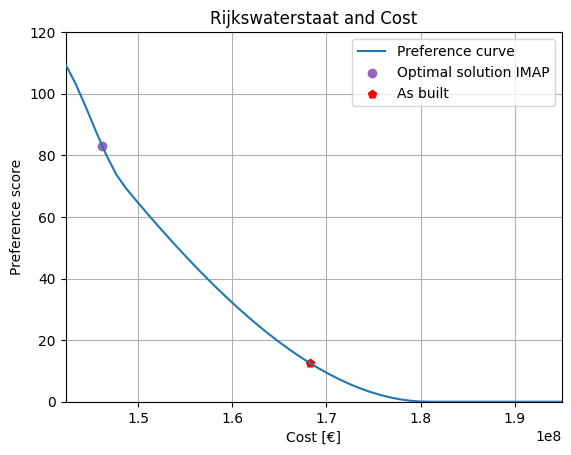

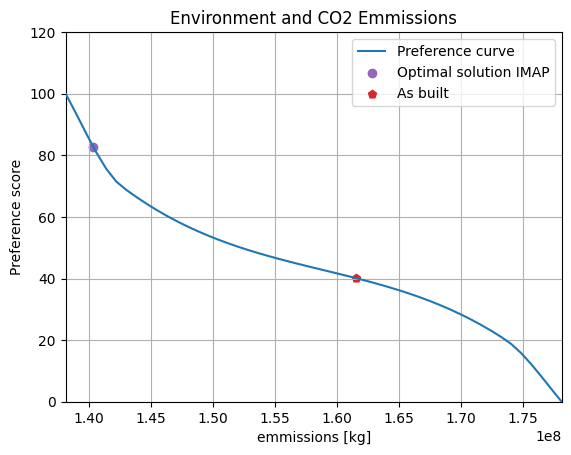

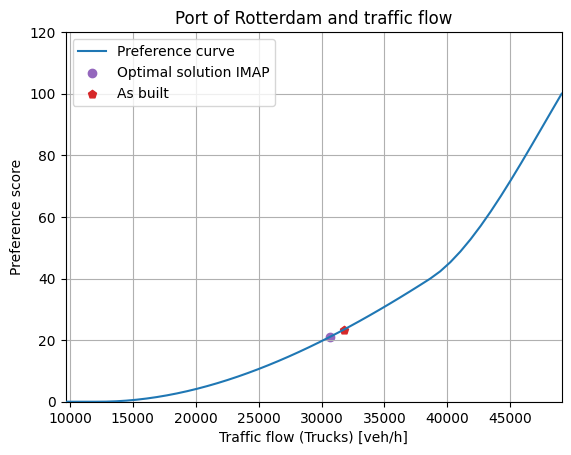

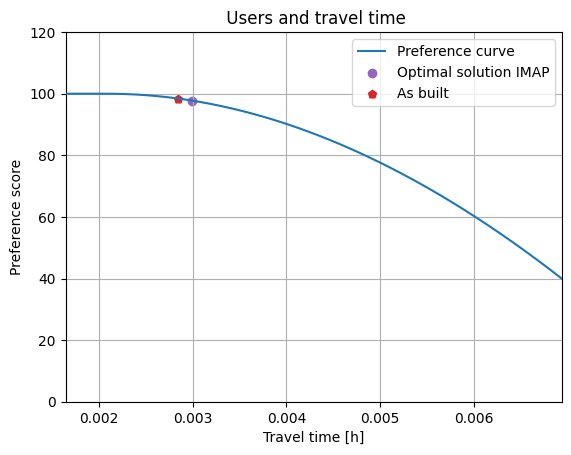

In [14]:
# arrays for plotting continuous preference curves
c1 = np.linspace(142319812.176, 194979798.828)
c2 = np.linspace(138100845.216, 178103930.988)
c3 = np.linspace(9661.835748792271, 49079.75460122699)
c4 = np.linspace(0.0016454566216564416, 0.006937812476468866)

# calculate the preference functions
p1 = pchip_interpolate(x_points_1, p_points_1, c1)
p2 = pchip_interpolate(x_points_2, p_points_2, c2)
p3 = pchip_interpolate(x_points_3, p_points_3, c3)
p4 = pchip_interpolate(x_points_4, p_points_4, c4)

# make numpy array of results, to allow for array splicing
variable = np.array(save_array)

# calculate individual preference scores for the results of the GA, to plot them on the preference curves
# first for the optimization results
c1_res = objective_costs(variable[:, 0], variable[:, 1], variable[:, 2])
c2_res = objective_emissions(variable[:, 0], variable[:, 1], variable[:, 2])
c3_res = objective_traffic_flow(variable[:, 0], variable[:, 1])
c4_res = objective_travel_time(variable[:, 0], variable[:, 1])

p1_res = pchip_interpolate(x_points_1, p_points_1, c1_res)
p2_res = pchip_interpolate(x_points_2, p_points_2, c2_res)
p3_res = pchip_interpolate(x_points_3, p_points_3, c3_res)
p4_res = pchip_interpolate(x_points_4, p_points_4, c4_res)

# and secondly, for the as-built solution, so we can compare the two.
c1_res_actual = objective_costs(945, 6, 28)
c2_res_actual = objective_emissions(945, 6, 28)
c3_res_actual = objective_traffic_flow(945, 6)
c4_res_actual = objective_travel_time(945, 6)

p1_res_actual = pchip_interpolate(x_points_1, p_points_1, c1_res_actual)
p2_res_actual = pchip_interpolate(x_points_2, p_points_2, c2_res_actual)
p3_res_actual = pchip_interpolate(x_points_3, p_points_3, c3_res_actual)
p4_res_actual = pchip_interpolate(x_points_4, p_points_4, c4_res_actual)

# create figure that plots all preference curves and the preference scores of the returned results of the GA
fig = plt.figure()
ax1 = fig.add_subplot(1, 1, 1)
ax1.plot(c1, p1, zorder=3, label='Preference curve')
ax1.scatter(c1_res, p1_res, label='Optimal solution IMAP', color='tab:purple', zorder=1)
ax1.scatter(c1_res_actual, p1_res_actual, label='As built', marker='p', color='r', zorder=1)
ax1.set_xlim((142319812.176, 194979798.828))
ax1.set_ylim((0, 120))
ax1.set_title('Rijkswaterstaat and Cost')
ax1.set_xlabel('Cost [€]')
ax1.set_ylabel('Preference score')
ax1.legend()
ax1.grid()
plt.savefig('Cost.png')

fig = plt.figure()
ax2 = fig.add_subplot(1, 1, 1)
ax2.plot(c2, p2, zorder=3, label='Preference curve')
ax2.scatter(c2_res, p2_res, label='Optimal solution IMAP', color='tab:purple', zorder=1)
ax2.scatter(c2_res_actual, p2_res_actual, label='As built', marker='p', color='tab:red', zorder=1)
ax2.set_xlim((138100845.216, 178103930.988))
ax2.set_ylim((0, 120))
ax2.set_title('Environment and CO2 Emmissions')
ax2.set_xlabel('emmissions [kg]')
ax2.set_ylabel('Preference score')
ax2.legend()
ax2.grid()
plt.savefig(' Environment and CO2 Emmissions.png')

fig = plt.figure()
ax3 = fig.add_subplot(1, 1, 1)
ax3.plot(c3, p3, zorder=3, label='Preference curve')
ax3.scatter(c3_res, p3_res, label='Optimal solution IMAP', color='tab:purple', zorder=1)
ax3.scatter(c3_res_actual, p3_res_actual, label='As built', marker='p', color='tab:red', zorder=1)
ax3.set_xlim((9661.835748792271, 49079.75460122699))
ax3.set_ylim((0, 120))
ax3.set_title('Port of Rotterdam and traffic flow')
ax3.set_xlabel('Traffic flow (Trucks) [veh/h]')
ax3.set_ylabel('Preference score')
ax3.legend()
ax3.grid()
plt.savefig('traffic Flow.png')

fig = plt.figure()
ax4 = fig.add_subplot(1, 1, 1)
ax4.plot(c4, p4, zorder=3, label='Preference curve')
ax4.scatter(c4_res, p4_res, label='Optimal solution IMAP', color='tab:purple')
ax4.scatter(c4_res_actual, p4_res_actual, label='As built', marker='p', color='tab:red')
ax4.set_xlim((0.0016454566216564416, 0.006937812476468866))
ax4.set_ylim((0, 120))
ax4.set_title(' Users and travel time')
ax4.set_xlabel('Travel time [h]')
ax4.set_ylabel('Preference score')
ax4.legend()
ax4.grid()
plt.savefig('Travel time.png')
print()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=88990155-7c6b-42b7-9b34-d0621db6d6b1' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>